--- Analysis for Problem 1 (2 Masses) ---
G(s) = <TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              s + 1
  -----------------------------
  s^4 + 4 s^3 + 7 s^2 + 6 s + 3
Poles: [-1.5+0.8660254j -1.5-0.8660254j -0.5+0.8660254j -0.5-0.8660254j]
Rise Time: 1.4639 s
Settling Time: 8.6004 s
Overshoot: 24.2262 %


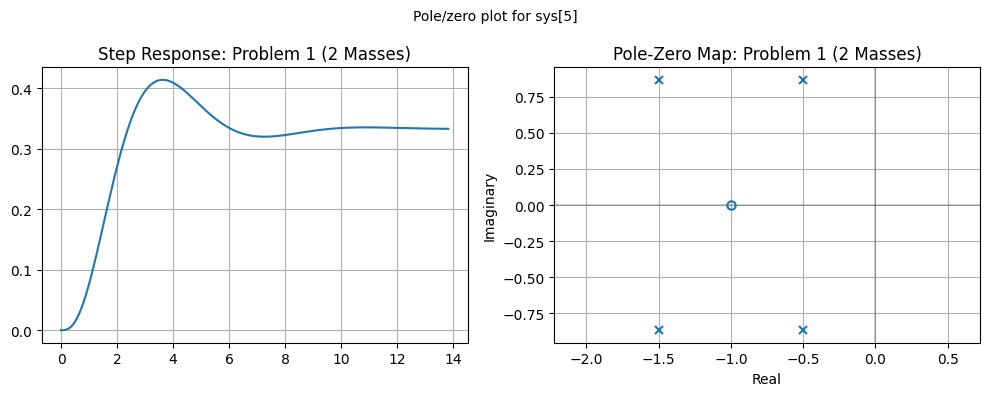

--- Analysis for Problem 2 (2 Inertias) ---
G(s) = <TransferFunction>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              1
  -------------------------
  s^4 + 2 s^3 + 3 s^2 + 2 s
Poles: [-0.5+1.32287566j -0.5-1.32287566j -1. +0.j          0. +0.j        ]
System contains poles with non-negative real parts...


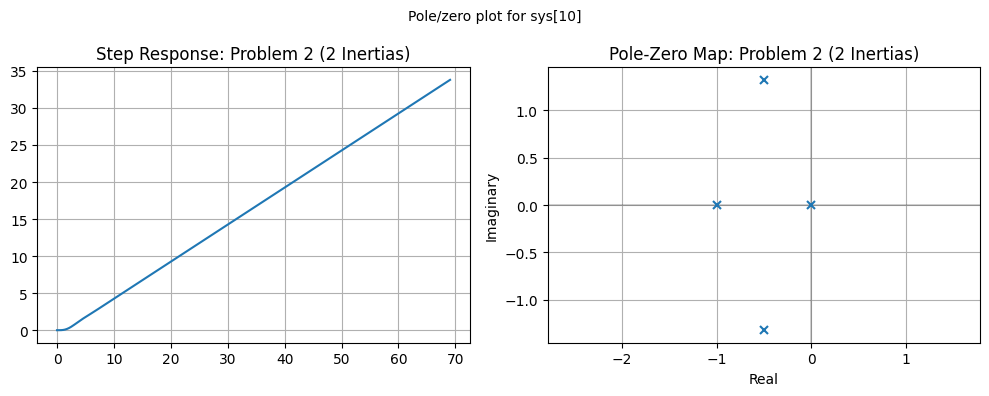

--- Analysis for Problem 3 (3 Masses) ---
G(s) = <TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          2 s^2 + s + 3
  ------------------------------
  8 s^4 + 12 s^3 + 26 s^2 + 18 s
Poles: [-0.33251681+1.60752974j -0.33251681-1.60752974j -0.83496638+0.j
  0.        +0.j        ]
System contains poles with non-negative real parts...


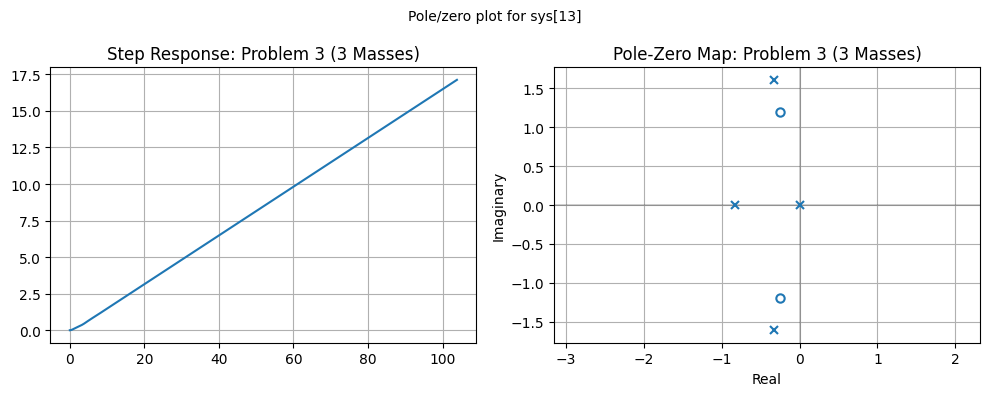

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

def analyze_and_plot(num, den, title):
    # Define the Transfer Function
    sys = ct.TransferFunction(num, den)
    print(f"--- Analysis for {title} ---")
    print(f"G(s) = {sys}")
    
    # Calculate poles
    poles = ct.poles(sys)
    print(f"Poles: {poles}")
    
    # Attempt to calculate transient metrics
    if all(np.real(poles) < 0):
        try:
            info = ct.step_info(sys)
            print(f"Rise Time: {info['RiseTime']:.4f} s")
            print(f"Settling Time: {info['SettlingTime']:.4f} s")
            print(f"Overshoot: {info['Overshoot']:.4f} %")
        except:
            print("Transient metrics calculation skipped.")
    else:
        print("System contains poles with non-negative real parts...")

    plt.figure(figsize=(10, 4))
    
    # Step Response Plot
    plt.subplot(1, 2, 1)
    t, y = ct.step_response(sys)
    plt.plot(t, y)
    plt.title(f"Step Response: {title}")
    plt.grid(True)
    
    # Pole-Zero Map
    plt.subplot(1, 2, 2)
    ct.pole_zero_plot(sys)
    plt.title(f"Pole-Zero Map: {title}")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Problem 1
num1 = [1, 1]
den1 = [1, 4, 7, 6, 3]
analyze_and_plot(num1, den1, "Problem 1 (2 Masses)")

# Problem 2
num2 = [1]
den2 = [1, 2, 3, 2, 0]
analyze_and_plot(num2, den2, "Problem 2 (2 Inertias)")

# Problem 3
num3 = [2, 1, 3]
den3 = [8, 12, 26, 18, 0]
analyze_and_plot(num3, den3, "Problem 3 (3 Masses)")